In [1]:
# # 🌾 AgriIntel

# # Phase 9A

# ## Advanced Statistical Analysis

# ### Objectives

# In this notebook we will perform:

# - Descriptive Statistics
# - Distribution Analysis
# - Outlier Detection
# - Normality Testing
# - Confidence Intervals
# - Hypothesis Testing
# - ANOVA
# - Chi-Square Test

# The objective is to statistically validate agricultural insights instead of relying only on visual analysis.

In [2]:
# ============================================================
# AgriIntel
# Phase 9A
# Advanced Statistical Analysis
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns",None)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
master = pd.read_csv("../data/final/master_dataset_featured.csv")

print(master.shape)

master.head()

(345374, 40)


,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,Start_Year,Year_yield,Area_yield,Production_yield,fertilizer,pesticide,Yield_yield,Year_weather,avg_temp_c,total_rainfall_mm,avg_humidity_percent,N,P,K,pH,End_Year,Decade,Year_Group,Rainfall_Category,Temperature_Category,Humidity_Category,Production_per_Hectare,Fertilizer_per_Hectare,Pesticide_per_Hectare,Rainfall_per_Hectare,Crop_Category,Production_Level,Yield_Level,Weather_Data_Available,Soil_Data_Available
0,Andaman And Nicobar Islands,Nicobars,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.643541,NaN,NaN,NaN,Other,Medium,Medium,False,False
1,Andaman And Nicobar Islands,Nicobars,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.655803,NaN,NaN,NaN,Other,Medium,Medium,False,False
2,Andaman And Nicobar Islands,Nicobars,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004,2000,2001-2005,NaN,NaN,NaN,1.209358,NaN,NaN,NaN,Other,Medium,Medium,False,False
3,Andaman And Nicobar Islands,North And Middle Andaman,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2002,2000,2001-2005,NaN,NaN,NaN,1.690000,NaN,NaN,NaN,Other,High,Medium,False,False
4,Andaman And Nicobar Islands,South Andamans,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,2000,2001-2005,NaN,NaN,NaN,1.696296,NaN,NaN,NaN,Other,High,Medium,False,False


In [4]:
print("="*70)

print("ADVANCED STATISTICAL ANALYSIS")

print("="*70)

print()

master.info()

ADVANCED STATISTICAL ANALYSIS

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345374 entries, 0 to 345373
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   State                   345374 non-null  object 
 1   District                345374 non-null  object 
 2   Crop                    345374 non-null  object 
 3   Year                    345374 non-null  object 
 4   Season                  345374 non-null  object 
 5   Area                    345374 non-null  float64
 6   Area Units              345374 non-null  object 
 7   Production              340414 non-null  float64
 8   Production Units        345374 non-null  object 
 9   Yield                   345374 non-null  float64
 10  Start_Year              345374 non-null  int64  
 11  Year_yield              318023 non-null  float64
 12  Area_yield              318023 non-null  float64
 13  Production_yield        318023 non-null  fl

In [5]:
# DESCRIPTIVE STATISTICS

In [6]:
numeric = master.select_dtypes(include=np.number)

summary = numeric.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Area,345374.0,1.167019e+04,4.583843e+04,0.004000,7.400000e+01,5.320000e+02,4.110000e+03,8.580100e+06
Production,340414.0,9.583711e+05,2.152986e+07,0.000000,8.700000e+01,7.170000e+02,7.176000e+03,1.597800e+09
Yield,345374.0,7.940757e+01,9.166287e+02,0.000000,5.467421e-01,1.000000e+00,2.467080e+00,4.395833e+04
Start_Year,345374.0,2.008887e+03,6.564329e+00,1997.000000,2.003000e+03,2.009000e+03,2.015000e+03,2.020000e+03
Year_yield,318023.0,2.008930e+03,6.564855e+00,1997.000000,2.003000e+03,2.009000e+03,2.015000e+03,2.020000e+03
Area_yield,318023.0,3.757167e+05,1.059462e+06,0.500000,7.527000e+03,4.593800e+04,2.491024e+05,1.021652e+07
Production_yield,318023.0,2.265875e+07,3.006509e+08,0.000000,8.585000e+03,6.158300e+04,4.442000e+05,6.326000e+09
fertilizer,318023.0,5.069959e+07,1.472903e+08,54.170000,1.012969e+06,6.176343e+06,3.280140e+07,1.754789e+09
pesticide,318023.0,1.025212e+05,3.041488e+05,0.090000,2.001185e+03,1.159000e+04,6.427510e+04,3.780111e+06
Yield_yield,318023.0,8.521485e+01,8.946172e+02,0.000000,6.086957e-01,1.081905e+00,2.519231e+00,2.110500e+04


In [7]:
summary["Variance"] = numeric.var()

summary["Skewness"] = numeric.skew()

summary["Kurtosis"] = numeric.kurt()

summary

,count,mean,std,min,25%,50%,75%,max,Variance,Skewness,Kurtosis
Area,345374.0,1.167019e+04,4.583843e+04,0.004000,7.400000e+01,5.320000e+02,4.110000e+03,8.580100e+06,2.101161e+09,41.849724,5419.285663
Production,340414.0,9.583711e+05,2.152986e+07,0.000000,8.700000e+01,7.170000e+02,7.176000e+03,1.597800e+09,4.635347e+14,35.874967,1584.402296
Yield,345374.0,7.940757e+01,9.166287e+02,0.000000,5.467421e-01,1.000000e+00,2.467080e+00,4.395833e+04,8.402083e+05,14.764971,260.575680
Start_Year,345374.0,2.008887e+03,6.564329e+00,1997.000000,2.003000e+03,2.009000e+03,2.015000e+03,2.020000e+03,4.309041e+01,-0.120397,-1.189480
Year_yield,318023.0,2.008930e+03,6.564855e+00,1997.000000,2.003000e+03,2.009000e+03,2.015000e+03,2.020000e+03,4.309732e+01,-0.129493,-1.185393
Area_yield,318023.0,3.757167e+05,1.059462e+06,0.500000,7.527000e+03,4.593800e+04,2.491024e+05,1.021652e+07,1.122460e+12,5.501320,36.594478
Production_yield,318023.0,2.265875e+07,3.006509e+08,0.000000,8.585000e+03,6.158300e+04,4.442000e+05,6.326000e+09,9.039095e+16,16.364691,279.856641
fertilizer,318023.0,5.069959e+07,1.472903e+08,54.170000,1.012969e+06,6.176343e+06,3.280140e+07,1.754789e+09,2.169444e+16,5.928269,44.187926
pesticide,318023.0,1.025212e+05,3.041488e+05,0.090000,2.001185e+03,1.159000e+04,6.427510e+04,3.780111e+06,9.250648e+10,6.129908,47.502519
Yield_yield,318023.0,8.521485e+01,8.946172e+02,0.000000,6.086957e-01,1.081905e+00,2.519231e+00,2.110500e+04,8.003400e+05,11.988651,151.480693


In [8]:
# DISTRIBUTION ANALYSIS

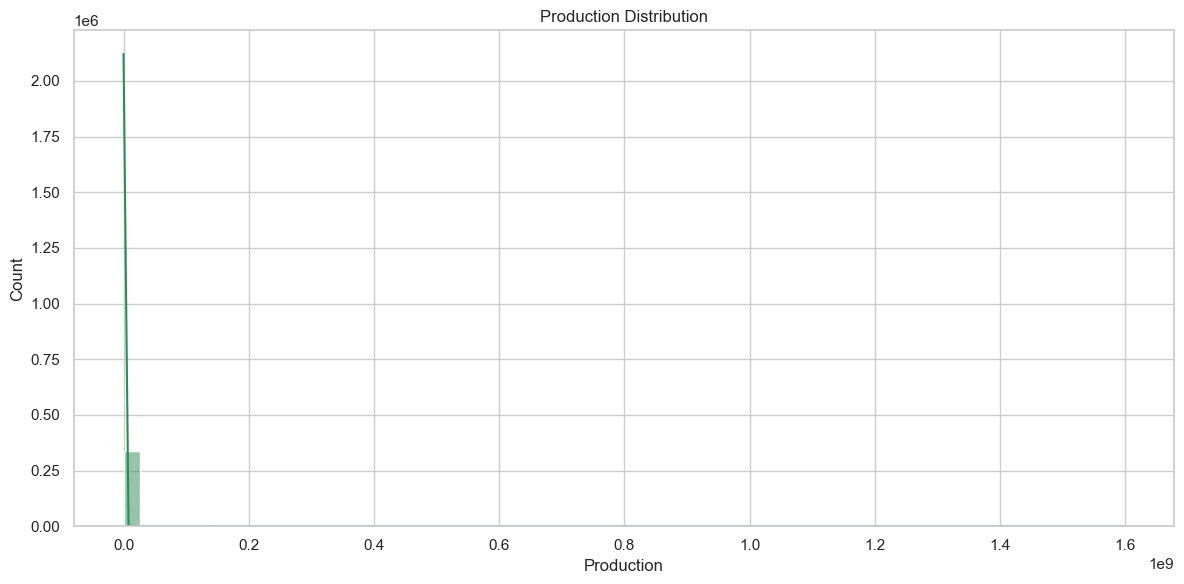

In [9]:
plt.figure(figsize=(12,6))

sns.histplot(

    master["Production"],

    bins=60,

    kde=True,

    color="#2E8B57"

)

plt.title("Production Distribution")

plt.tight_layout()

plt.show()

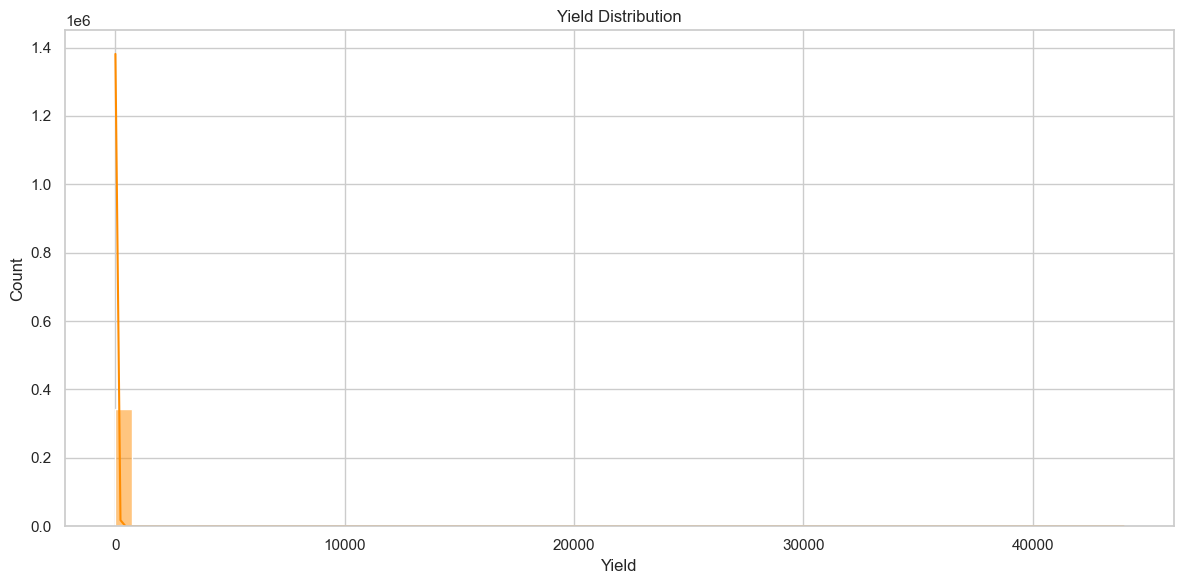

In [10]:
plt.figure(figsize=(12,6))

sns.histplot(

    master["Yield"],

    bins=60,

    kde=True,

    color="#FF8C00"

)

plt.title("Yield Distribution")

plt.tight_layout()

plt.show()

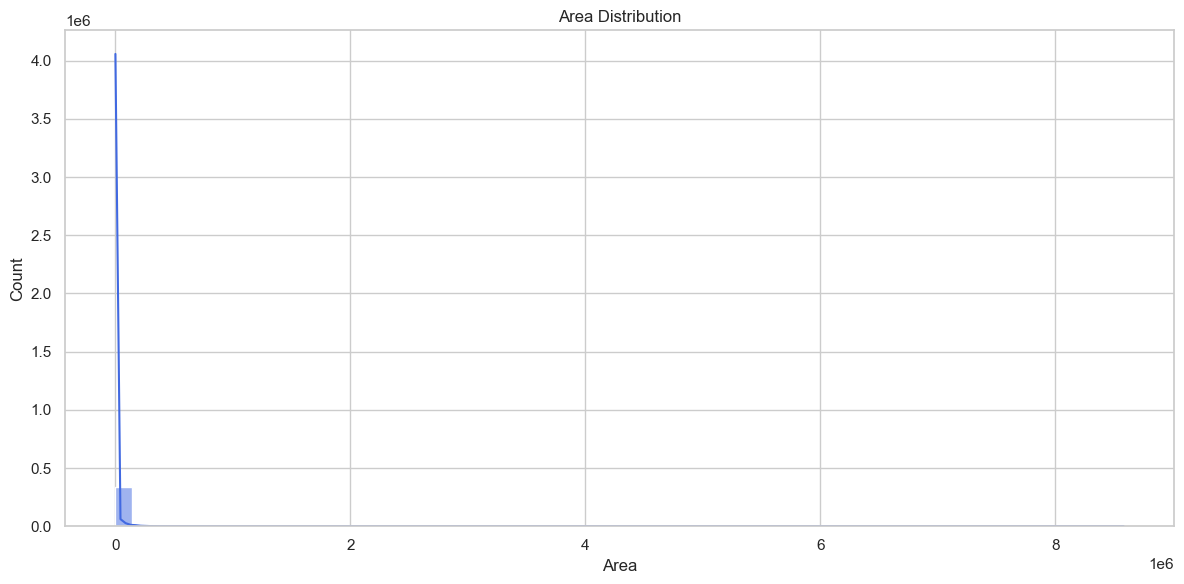

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(

    master["Area"],

    bins=60,

    kde=True,

    color="#4169E1"

)

plt.title("Area Distribution")

plt.tight_layout()

plt.show()

In [12]:
# OUTLIER DETECTION

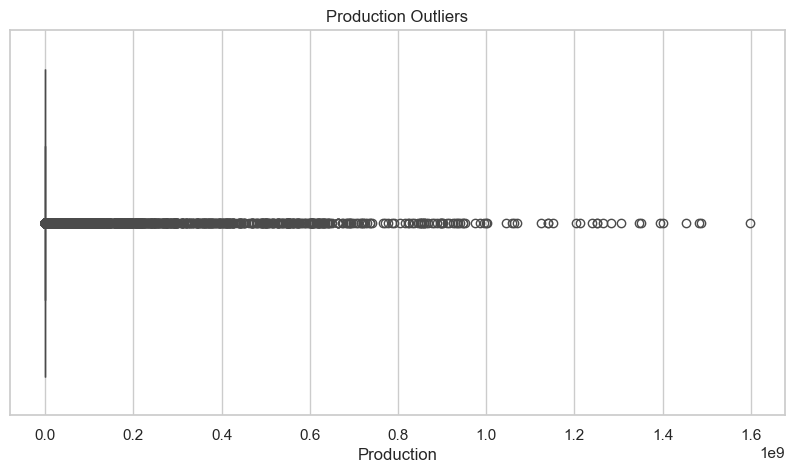

In [13]:
plt.figure(figsize=(10,5))

sns.boxplot(

    x=master["Production"],

    color="#4CAF50"

)

plt.title("Production Outliers")

plt.show()

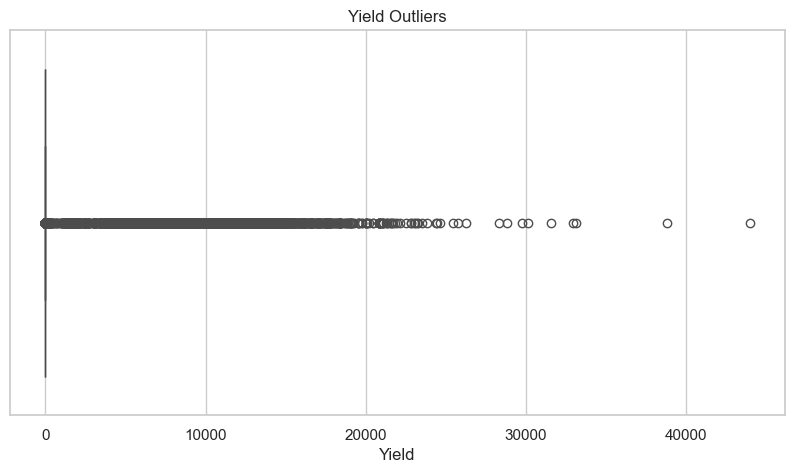

In [14]:
plt.figure(figsize=(10,5))

sns.boxplot(

    x=master["Yield"],

    color="#FF9800"

)

plt.title("Yield Outliers")

plt.show()

In [15]:
Q1 = master["Production"].quantile(0.25)

Q3 = master["Production"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = master[
    (master["Production"]<lower) |
    (master["Production"]>upper)
]

print("Production Outliers")

print(outliers.shape[0])

Production Outliers
60092


In [16]:
# NORMALITY TEST

In [17]:
sample = master["Yield"].dropna().sample(5000, random_state=42)

stat, p = stats.shapiro(sample)

print("Statistic :", stat)

print("P-value :", p)

Statistic : 0.06330059676826727
P-value : 2.6097317695675356e-94


In [18]:
if p > 0.05:

    print("Yield follows Normal Distribution")

else:

    print("Yield does NOT follow Normal Distribution")

Yield does NOT follow Normal Distribution


In [19]:
# CONFIDENCE INTERVAL

In [20]:
yield_sample = master["Yield"].dropna()

mean = yield_sample.mean()

std = yield_sample.std()

n = len(yield_sample)

margin = 1.96 * (std/np.sqrt(n))

lower = mean-margin

upper = mean+margin

print("95% Confidence Interval")

print(lower)

print(upper)

95% Confidence Interval
76.35050396105196
82.46463466743496


In [22]:
# HYPOTHESIS TESTING

In [23]:
kharif = master[
    master["Season"]=="Kharif"
]["Yield"].dropna()

rabi = master[
    master["Season"]=="Rabi"
]["Yield"].dropna()

stat,p = stats.ttest_ind(

    kharif,

    rabi,

    equal_var=False

)

print(stat)

print(p)

3.2177800623844726
0.0012921063720404762


In [24]:
if p < 0.05:

    print("Reject Null Hypothesis")

    print("Yield differs significantly")

else:

    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis
Yield differs significantly


In [25]:
# ANOVA

In [26]:
groups = []

for season in master["Season"].dropna().unique():

    groups.append(

        master[

            master["Season"]==season

        ]["Yield"].dropna()

    )

f,p = stats.f_oneway(*groups)

print("F Statistic :",f)

print("P-value :",p)

F Statistic : 2016.087201749349
P-value : 0.0


In [27]:
if p<0.05:

    print("Season significantly affects Yield")

else:

    print("No significant difference")

Season significantly affects Yield


In [28]:
# CHI-SQUARE TEST

In [29]:
table = pd.crosstab(

    master["Season"],

    master["Production_Level"]

)

table

Production_Level,High,Low,Medium
Season,,,
Autumn,3057,1827,2083
Kharif,43969,47461,44735
Rabi,31896,32647,35262
Summer,5532,7995,8447
Whole Year,24821,21315,21129
Winter,4190,2263,1785


In [30]:
chi,p,dof,expected = stats.chi2_contingency(table)

print("Chi Square :",chi)

print("P-value :",p)

Chi Square : 2937.561688085249
P-value : 0.0


In [31]:
if p<0.05:

    print("Season and Production Level are associated.")

else:

    print("No significant association.")

Season and Production Level are associated.


In [32]:
# FINAL VERIFICATION

In [33]:
print("="*70)

print("PHASE 9A VERIFICATION")

print("="*70)

verification = pd.DataFrame({

"Analysis":[

"Descriptive Statistics",

"Distribution",

"Outlier Detection",

"Normality Test",

"Confidence Interval",

"Hypothesis Testing",

"ANOVA",

"Chi-Square"

],

"Status":[

"Completed",

"Completed",

"Completed",

"Completed",

"Completed",

"Completed",

"Completed",

"Completed"

]

})

display(verification)

print()

print("STATUS : PASS")

PHASE 9A VERIFICATION


,Analysis,Status
0,Descriptive Statistics,Completed
1,Distribution,Completed
2,Outlier Detection,Completed
3,Normality Test,Completed
4,Confidence Interval,Completed
5,Hypothesis Testing,Completed
6,ANOVA,Completed
7,Chi-Square,Completed



STATUS : PASS


In [35]:
# # Phase 9B

# ## Business Intelligence & Machine Learning Insights

# Objectives

# - Productivity Index
# - State Performance Score
# - Crop Diversity Analysis
# - Agricultural Efficiency Ranking
# - K-Means Clustering
# - Principal Component Analysis (PCA)
# - Executive Insights

In [36]:
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [38]:
# Productivity Index

In [39]:
master["Productivity_Index"] = (

    master["Yield"]

    *

    master["Production_per_Hectare"]

)

In [40]:
master["Productivity_Index"].describe()

count    3.404140e+05
mean     8.588455e+05
std      1.384696e+07
min      0.000000e+00
25%      3.225333e-01
50%      1.050625e+00
75%      6.250000e+00
max      1.932335e+09
Name: Productivity_Index, dtype: float64

In [42]:
# State Productivity

state_productivity = (

    master.groupby("State")["Productivity_Index"]

    .mean()

    .sort_values(ascending=False)

)

state_productivity.head(10)

State
Puducherry                     9.579475e+06
West Bengal                    5.783402e+06
Tamil Nadu                     4.058675e+06
Kerala                         2.880313e+06
Andhra Pradesh                 2.703642e+06
Assam                          2.348280e+06
Goa                            1.818771e+06
Andaman And Nicobar Islands    1.759234e+06
Karnataka                      1.184523e+06
Telangana                      3.047027e+05
Name: Productivity_Index, dtype: float64

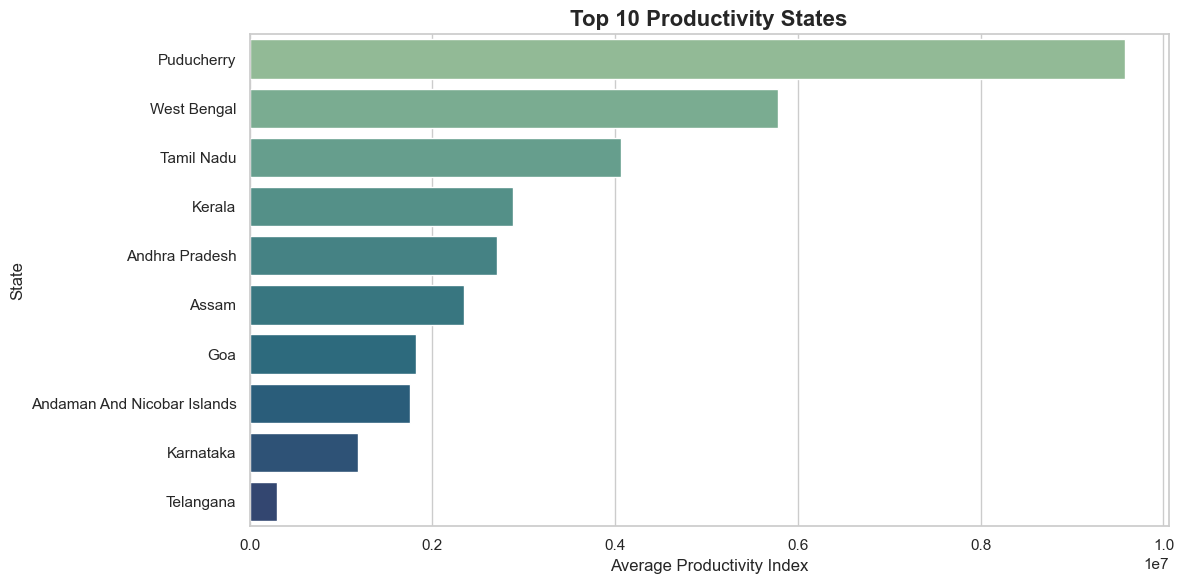

In [43]:
plt.figure(figsize=(12,6))

colors = sns.color_palette("crest",10)

sns.barplot(

    x=state_productivity.head(10).values,

    y=state_productivity.head(10).index,

    palette=colors

)

plt.title("Top 10 Productivity States",fontsize=16,fontweight="bold")

plt.xlabel("Average Productivity Index")

plt.ylabel("State")

plt.tight_layout()

plt.show()

In [44]:
# Crop Diversity

crop_diversity = (

    master.groupby("State")["Crop"]

    .nunique()

    .sort_values(ascending=False)

)

crop_diversity.head(10)

State
Andhra Pradesh    47
Tamil Nadu        46
Madhya Pradesh    45
Karnataka         45
Chhattisgarh      44
West Bengal       43
Bihar             42
Telangana         42
Rajasthan         41
Odisha            40
Name: Crop, dtype: int64

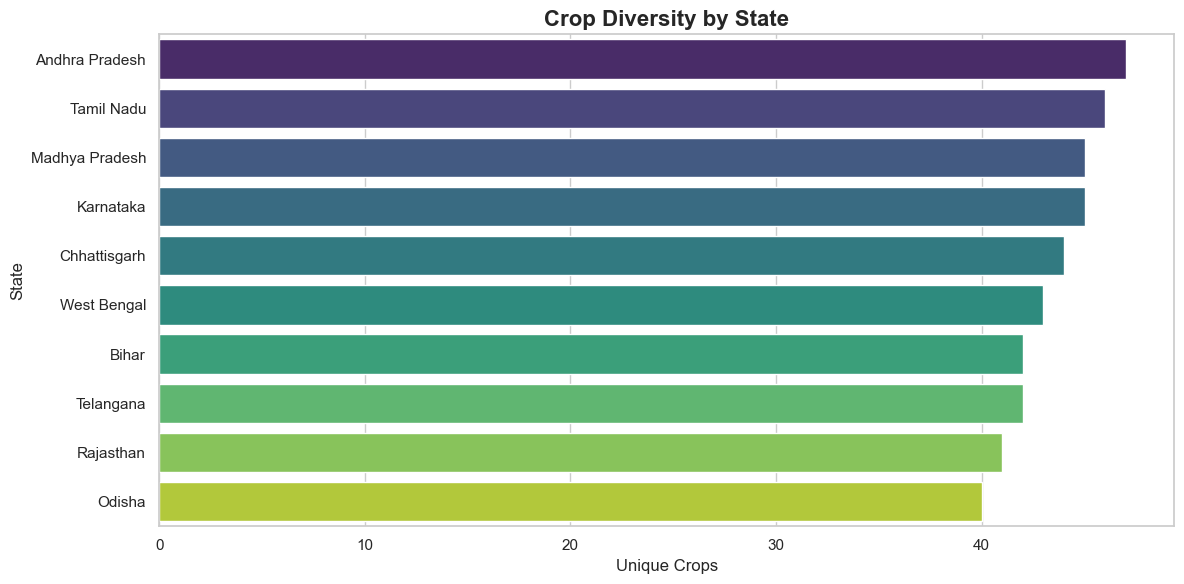

In [45]:
plt.figure(figsize=(12,6))

colors=sns.color_palette("viridis",10)

sns.barplot(

    x=crop_diversity.head(10).values,

    y=crop_diversity.head(10).index,

    palette=colors

)

plt.title("Crop Diversity by State",fontsize=16,fontweight="bold")

plt.xlabel("Unique Crops")

plt.ylabel("State")

plt.tight_layout()

plt.show()

In [47]:
# State Performance Score

state_score = (

master.groupby("State")[

["Production","Yield","Area"]

]

.mean()

)

In [48]:
scaler = StandardScaler()

scaled = scaler.fit_transform(state_score)

state_score["Performance_Score"] = scaled.mean(axis=1)

state_score = state_score.sort_values(

"Performance_Score",

ascending=False

)

state_score.head(10)

,Production,Yield,Area,Performance_Score
State,,,,
Kerala,2.794068e+07,422.329994,7472.496980,2.508962
West Bengal,7.107456e+05,430.561452,18869.662184,1.028191
Punjab,1.907153e+05,6.747059,39121.245775,0.979294
Puducherry,4.397289e+05,779.961428,579.894410,0.956214
Goa,5.512572e+06,362.442833,6894.487469,0.772857
Tamil Nadu,4.323958e+06,303.255555,5958.103428,0.539113
Andhra Pradesh,1.613428e+06,212.827867,14601.560533,0.512386
Maharashtra,1.066458e+05,3.819867,25775.000120,0.445500
Rajasthan,2.984168e+04,3.312462,23889.081422,0.365262


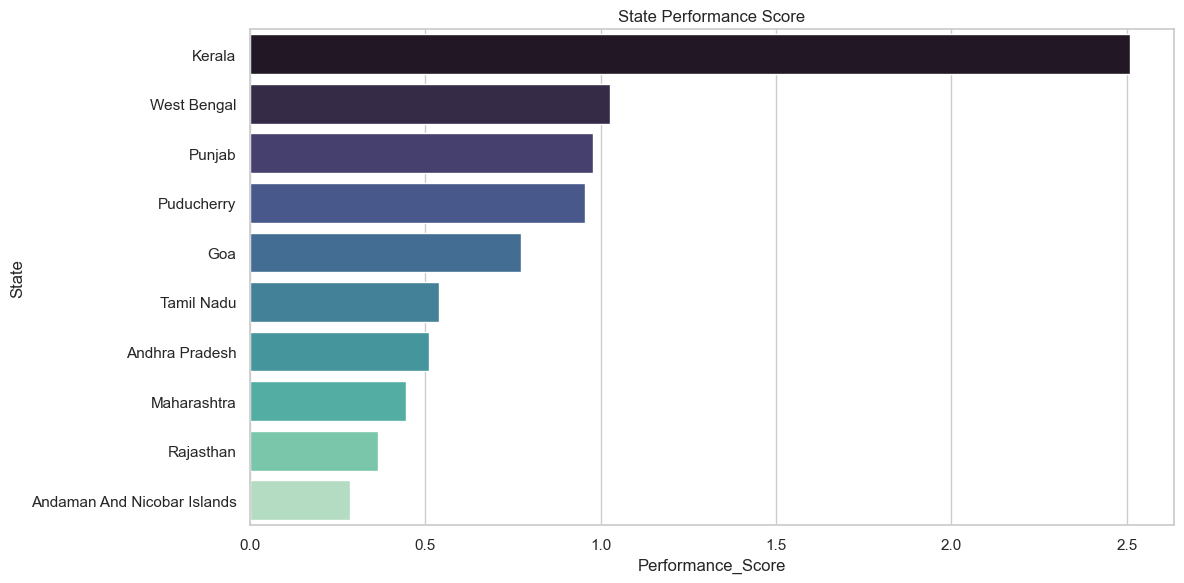

In [49]:
plt.figure(figsize=(12,6))

colors=sns.color_palette("mako",10)

sns.barplot(

x=state_score.head(10)["Performance_Score"],

y=state_score.head(10).index,

palette=colors

)

plt.title("State Performance Score")

plt.tight_layout()

plt.show()

In [50]:
# Agricultural Efficiency

master["Efficiency"] = (

master["Production"]

/

master["Area"]

)

In [51]:
efficiency = (

master.groupby("State")["Efficiency"]

.mean()

.sort_values(ascending=False)

)

efficiency.head(10)

State
Puducherry                     782.739563
Kerala                         443.073475
West Bengal                    431.109066
Goa                            363.353494
Andaman And Nicobar Islands    325.629373
Tamil Nadu                     311.218723
Assam                          228.842645
Andhra Pradesh                 215.474717
Karnataka                      158.464287
Telangana                       22.676743
Name: Efficiency, dtype: float64

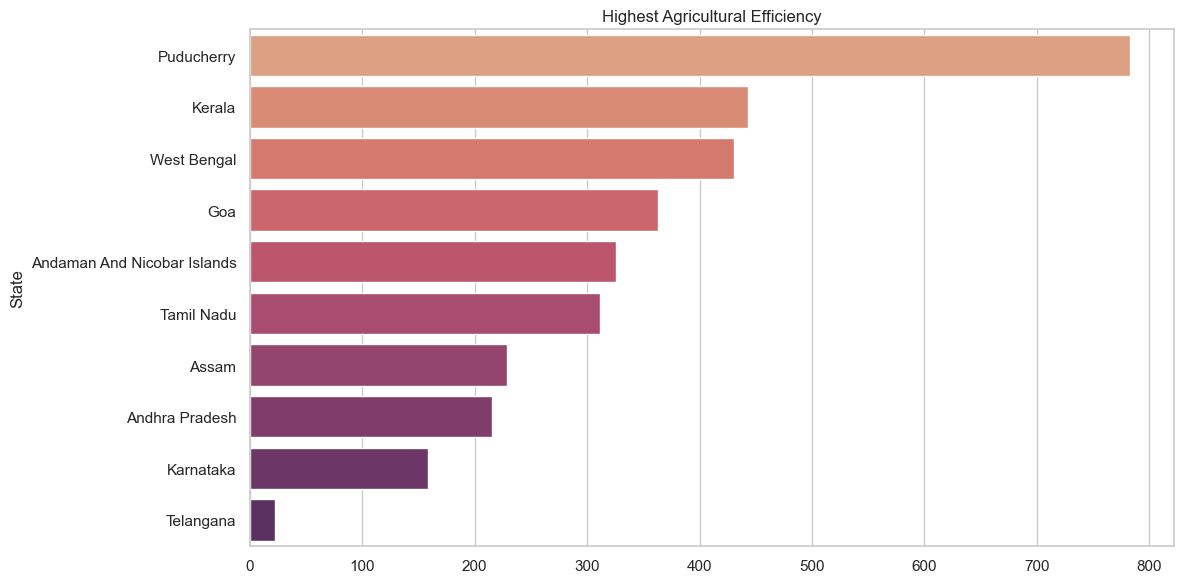

In [52]:
plt.figure(figsize=(12,6))

colors=sns.color_palette("flare",10)

sns.barplot(

x=efficiency.head(10).values,

y=efficiency.head(10).index,

palette=colors

)

plt.title("Highest Agricultural Efficiency")

plt.tight_layout()

plt.show()

In [53]:
# KMeans Clustering

cluster_data = master[

[

"Production",

"Yield",

"Area"

]

].dropna()

In [54]:
scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_data)

In [55]:
kmeans = KMeans(

n_clusters=4,

random_state=42,

n_init=10

)

cluster_data["Cluster"] = kmeans.fit_predict(scaled)

cluster_data.head()

,Production,Yield,Area,Cluster
0,2061.0,1.643541,1254.0,0
1,2083.0,1.655803,1258.0,0
2,1525.0,1.209358,1261.0,0
3,5239.0,1.690000,3100.0,0
4,5267.0,1.696296,3105.0,0


In [56]:
cluster_data["Cluster"].value_counts()

Cluster
0    326532
2     11606
3      1968
1       308
Name: count, dtype: int64

In [57]:
# PCA
pca = PCA(n_components=2)

components = pca.fit_transform(scaled)


In [62]:
pca_df = pd.DataFrame(

components,

columns=["PC1","PC2"]

)

pca_df["Cluster"] = cluster_data["Cluster"].values

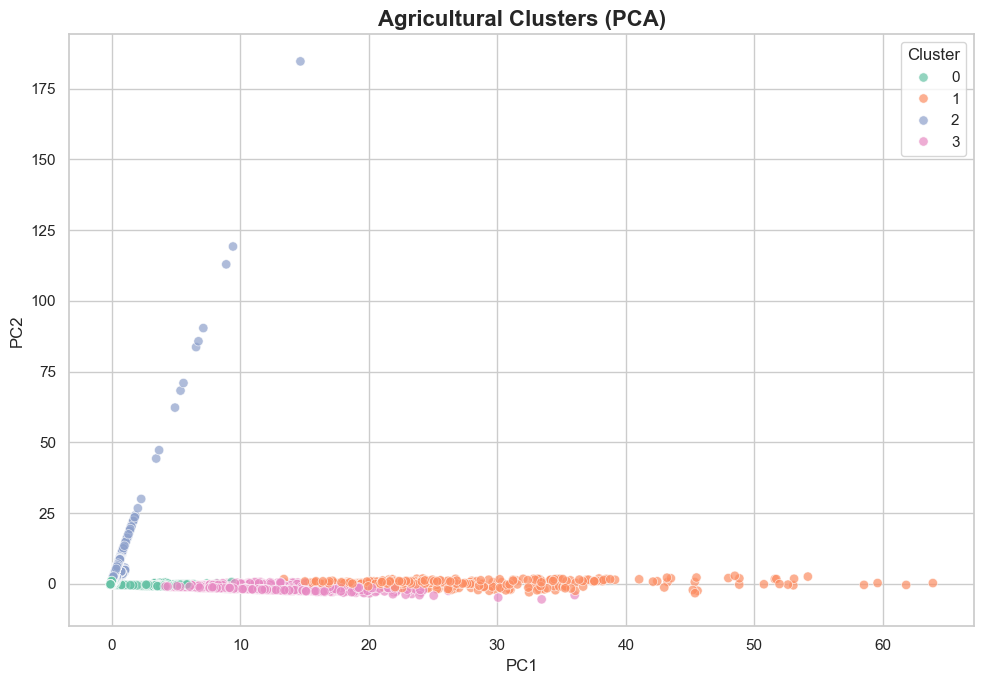

In [63]:
plt.figure(figsize=(10,7))

sns.scatterplot(

data=pca_df,

x="PC1",

y="PC2",

hue="Cluster",

palette="Set2",

s=45,

alpha=.7

)

plt.title("Agricultural Clusters (PCA)",fontsize=16,fontweight="bold")

plt.tight_layout()

plt.show()

In [64]:
# Cluster Summary

In [65]:
cluster_summary = (

cluster_data

.groupby("Cluster")

.mean()

)

cluster_summary

,Production,Yield,Area
Cluster,,,
0,5.857862e+04,11.738568,5775.462740
1,6.249279e+08,9351.931479,75304.863377
2,5.880757e+05,3.639878,181253.700733
3,5.478261e+07,10502.872222,6511.946555


In [66]:
# Executive Insights

insights = pd.DataFrame({

"Insight":[

"Best Productivity State",

"Highest Crop Diversity",

"Highest Efficiency",

"Number of Clusters"

],

"Value":[

state_productivity.idxmax(),

crop_diversity.idxmax(),

efficiency.idxmax(),

cluster_data["Cluster"].nunique()

]

})

insights

,Insight,Value
0,Best Productivity State,Puducherry
1,Highest Crop Diversity,Andhra Pradesh
2,Highest Efficiency,Puducherry
3,Number of Clusters,4


In [67]:
# Verification

print("="*70)

print("PHASE 9B VERIFICATION")

print("="*70)

verification = pd.DataFrame({

"Module":[

"Productivity Index",

"Crop Diversity",

"State Score",

"Efficiency",

"KMeans",

"PCA",

"Executive Insights"

],

"Status":[

"Completed",

"Completed",

"Completed",

"Completed",

"Completed",

"Completed",

"PASS"

]

})

display(verification)


PHASE 9B VERIFICATION


,Module,Status
0,Productivity Index,Completed
1,Crop Diversity,Completed
2,State Score,Completed
3,Efficiency,Completed
4,KMeans,Completed
5,PCA,Completed
6,Executive Insights,PASS
